In [1]:
import os, sys
import numpy as np
import pandas as pd
root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(root)
from utils import utils,models

In [2]:
device = utils.get_device()
print(f"Using device: {device}")
batch_size = 64

Using device: mps


In [3]:
model_name = 'ViT-L/14@336px'
model, preprocess = utils.load_model(model_name, device)
dataset_dir = '../dataset/newsimages_test_and_evaluation_26_v1.0'
images_dir = f'{dataset_dir}/news_images_evaluation'
dataset = pd.read_csv(f"{dataset_dir}/news_articles_evaluation.csv",encoding="latin-1")
dataset.set_index('article_id', inplace=True)
dataset['article_title'] = dataset['article_title'].apply(utils.normalize_text)
records = [
    {
        "image_path": utils.make_path(images_dir, row['image_id']),
        "title": row['article_title']
    }
    for _, row in dataset.iterrows()
]
image_paths = [r["image_path"] for r in records]
model_path = f"../artifacts/{model_name.replace('/','-')}_embeddings_evaluation_images.npy"
if os.path.exists(model_path):
    print("Using cached embeddings")
    image_embeddings = np.load(model_path)
else:
    image_embeddings = utils.encode_images(image_paths, model, preprocess, batch_size, device)
    np.save(model_path, image_embeddings)

Using cached embeddings


In [7]:
id_to_index = utils.build_id_to_index(image_paths)
article_titles,ground_truth = utils.build_ground_truth(dataset,images_dir,id_to_index)
data = [(q, img_id[0]) for q, img_id in ground_truth.items()]

In [5]:
retrieval_clip = models.CLIPRetrieval(model,image_embeddings,device)

In [6]:
mrr = utils.compute_mrr(retrieval_clip,data[:1000],10)

In [8]:
mrr

np.float64(0.37289404761904765)

In [9]:
queries = list(ground_truth.keys())
recalls = utils.evaluate(retrieval_clip,queries[:1000],ground_truth)
print('MMR@10 =',float(mrr))

MMR@10 = 0.37289404761904765


In [10]:
recalls

{1: np.float64(0.286), 5: np.float64(0.487), 10: np.float64(0.589)}

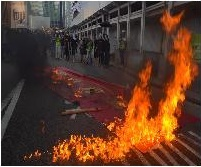

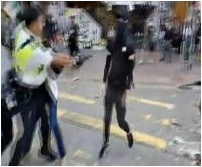

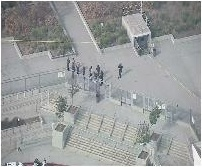

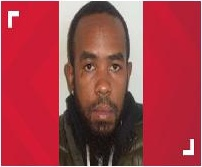

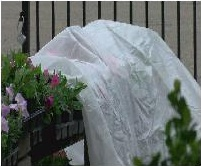

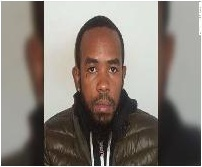

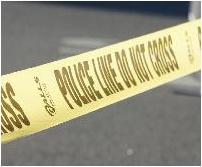

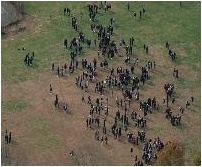

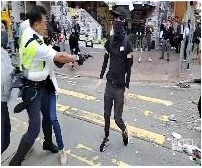

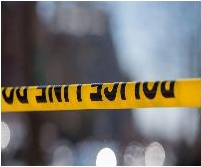

In [12]:
query = "Man shot dead during a protest in London"
candidates = utils.retrieve_candidates(query, model, device, image_embeddings, records)
candidates_indices = [candidate['idx'] for candidate in candidates]
utils.show_top_k_images(records,candidates_indices,10)

In [15]:
candidates

[{'idx': 8772,
  'image_path': '../dataset/newsimages_test_and_evaluation_26_v1.0/news_images_evaluation/266b3b5e69c542a4aa5f4fae2f43a460.jpg',
  'title': "Hong Kong's white-collar workers trade laptops for molotov cocktails",
  'clip_score': 0.2377307265996933,
  'image_emb': array([ 3.70508283e-02, -6.05814625e-03,  3.15267742e-02,  4.08963002e-02,
          1.69994328e-02,  5.24556125e-03,  2.69488320e-02,  1.42297763e-02,
          8.43104720e-03,  3.15572955e-02, -7.77296809e-05, -2.06579734e-03,
         -3.09011247e-03, -1.32149989e-02, -1.57176089e-02,  3.11757997e-02,
          1.93952229e-02,  1.27572045e-02,  1.29098026e-02, -1.41763678e-02,
          2.03871112e-02,  4.40245634e-03,  8.75150319e-03,  3.86073301e-03,
         -5.24022020e-02, -1.42583891e-03,  1.67705361e-02,  4.41390136e-03,
         -1.49240978e-02,  1.26503855e-02, -1.42297763e-02,  1.31615894e-02,
         -1.10404752e-02, -1.87543109e-02, -1.71367712e-02,  3.26254815e-02,
          1.82812568e-02, -2.49